# JAM Model of test galaxy with NFW halo
We perform multi-gaussian expansion on the stellar mass map from Pipe3D using photometry fromt he g-band weighted mean flux map from MaNGA . Then using the stellar velocity dispersion map from the MaNGA DAP (and assuming no rotation) we construct a JAM model for the galaxy assuming a NFW dark halo

### importing packages and data

In [1]:
#regular stuff
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
from astropy.table import Table
import astropy.io.fits as fits
from scipy.optimize import least_squares, minimize

#MGE
from mgefit.mge_fit_sectors import mge_fit_sectors
from mgefit.mge_fit_sectors_regularized import mge_fit_sectors_regularized
from mgefit.find_galaxy import find_galaxy
from mgefit.sectors_photometry import sectors_photometry
from mgefit.mge_print_contours import mge_print_contours, _gauss2d_mge
from mgefit.mge_print_contours_twist import mge_print_contours_twist
from mgefit.sectors_photometry_twist import sectors_photometry_twist
from mgefit.mge_fit_sectors_twist import mge_fit_sectors_twist
from mgefit.mge_fit_1d import mge_fit_1d


#JAM
import jampy as jam

#DATA
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals/')

from IO_data import extract_Pipe3d_data, extract_data

In [2]:
#DIRECTORIES
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'
master_table_fn = DATA_FOLDER + 'output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_v2.fits'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

### master table

In [79]:
master_table = Table.read(master_table_fn, format='fits')
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i
master_table[:5]


plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64

## test galaxy '8319-1902'

other test galaxies: 8143-3704, 8592-1901 
need to mask star sigma map if petals

### read in the data and display maps

In [450]:
test_gal = '8319-1902'
idx = master_table_dict[test_gal]
sMass_maps = extract_Pipe3d_data(PIPE3D_FOLDER, test_gal, ['sMass'])
flux_maps = extract_data(VEL_FOLDER, test_gal, ['flux'])
vel_maps = extract_data(VEL_FOLDER, test_gal, ['flux', 'Ha', 'star_sigma'])
PA = master_table[idx]['nsa_elpetro_phi']
ba = master_table[idx]['nsa_elpetro_ba']
z = master_table[idx]['nsa_z']

sMass = sMass_maps['sMass_density']
flux = flux_maps['mflux']
mask = np.logical_or(np.isnan(sMass), sMass == 0)
msMass = ma.array(sMass, mask = mask)
fmask = flux <= 0
mflux = ma.array(flux, mask=fmask)


H_0 = 100      # Hubble's Constant in units of h km/s/Mpc
c = 299792.458 # Speed of light in units of km/s

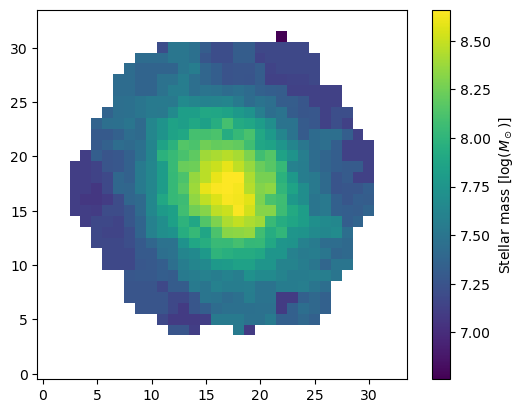

In [388]:
plt.imshow(msMass)
plt.gca().invert_yaxis()
plt.colorbar(label=r'Stellar mass [$\log(M_\odot)$]')

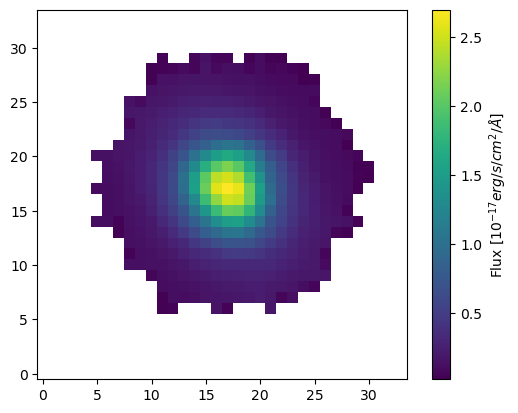

In [389]:
plt.imshow(mflux)
plt.gca().invert_yaxis()
plt.colorbar(label=r'Flux [$10^{-17} erg/s/cm^2/\AA$]')

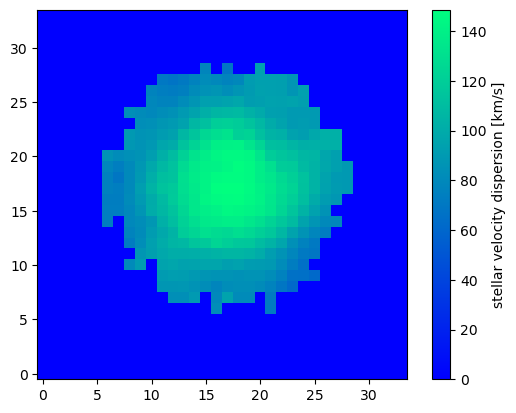

In [390]:
plt.imshow(vel_maps['star_sigma'], cmap='winter')
plt.gca().invert_yaxis()
plt.colorbar(label='stellar velocity dispersion [km/s]')

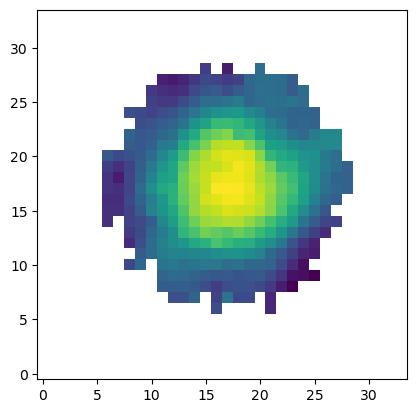

In [391]:
plt.imshow(ma.array(vel_maps['star_sigma'], mask=vel_maps['star_sigma_mask']))
plt.gca().invert_yaxis()

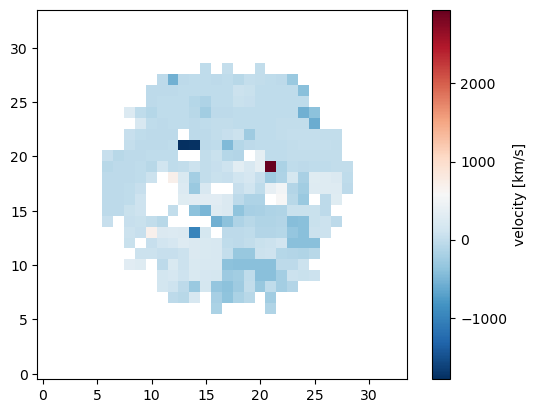

In [392]:
plt.imshow(ma.array(vel_maps['Ha_vel'], mask=vel_maps['Ha_vel_mask']), cmap='RdBu_r', 
           # vmin=-200, vmax=200
          )
plt.colorbar(label='velocity [km/s]')
plt.gca().invert_yaxis()

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   1.,   2.,   1.,
          2.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   1.,   1.,
          3.,   1.,   1.,  18.,   3.,   9.,   8.,   8.,  13.,  24., 113.,
        823.,  40.,  10.,  10.,  21.,  12.,   6.,   4.,   0.,   0.,   1.,
          1.,   0.,   2.,   0.,   0.,   1.,   0.,   0.,   1.,   1.,   0.,
          0.,   0.,   1.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   2.,
          0.,   1.,   0.,   1.,   1.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([-2341.00146484, -2288.14282227, -2235.28417969, -2182.42553711,
        -2129.56689453, -2076.70849609, -2023.84973145, -1970.99121094,
        -1918.13256836, -1865.27392578, -1812.4152832 , -1759.5567627 ,
        -1706.69812012, -1653.83947754, -1600.98083496, -1548.12231445,
        -1495.26367188, -1442.

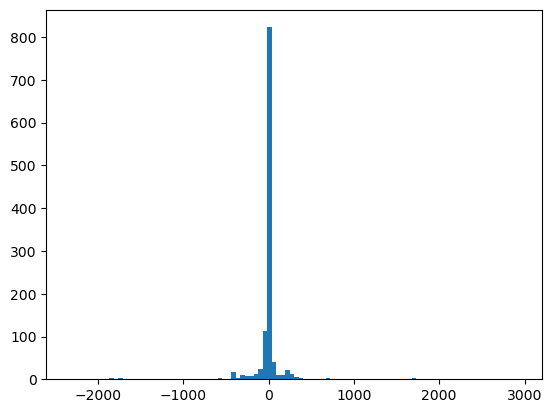

In [393]:
plt.hist(vel_maps['Ha_vel'].flatten(), bins=100)

### multi-gaussian expansion
use flux maps to find photometry (assuming no twists) and expand stellar mass map

In [394]:
sMass[mask]=0.

 Pixels used: 115
 Peak Img[j, k]: 17 17
 Mean (j, k): 17.02 17.04
 Theta (deg): 60.3
 Astro PA (deg): 29.7
 Eps: 0.220
 Major axis (pix): 6.7


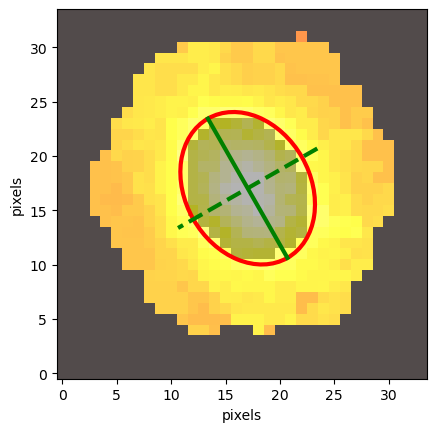

In [400]:
f = find_galaxy(10**sMass, fraction=0.1, plot=True)

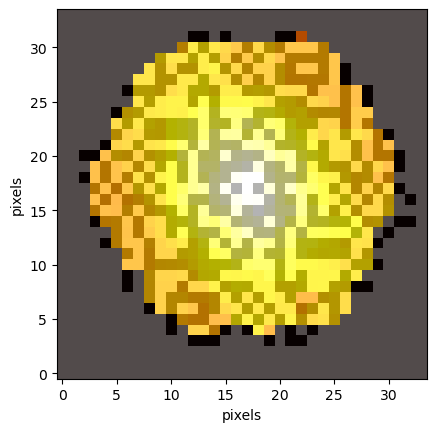

In [402]:
# set all stellar mass maps points that should be masked to 0

s = sectors_photometry(10**sMass, f.eps, f.theta, f.xpeak, f.ypeak,
                            plot=1, minlevel=6, #mask=sMass==0
                      )

Starting the LINEAR fit with  10000  Gaussians. Please wait...
Nonzero Gaussians: 9/10000
Eliminating not useful Gaussians...
ngauss: 8          chi2: 18.00
ngauss: 7          chi2: 18.01
ngauss: 6          chi2: 18.01
ngauss: 5          chi2: 18.01
ngauss: 4          chi2: 18.01
ngauss: 3          chi2: 18.16
Starting nonlinear fit...
Iteration: 0  chi2: 18.16  Nonzero: 3/3
Iteration: 3  chi2: 18.10  Nonzero: 3/3
Nonzero Gaussians: 3/3
Eliminating not useful Gaussians...
All Gaussians are needed!
############################################
  Computation time: 0.85 seconds
  Total Iterations:  0
 Nonzero Gaussians:  3
  Unused Gaussians:  9997
 Sectors used in the fit:  19
 Total number of points fitted:  223
 Chi2: 18.10 
 STDEV: 0.2731 
 MEANABSDEV: 0.1910 
############################################
  Total_Counts   sigma_Pixels     q_obs
############################################
   8.4790e+09        2.354       0.7718
   1.8671e+10        5.169       1.0000
   7.1806e+09      

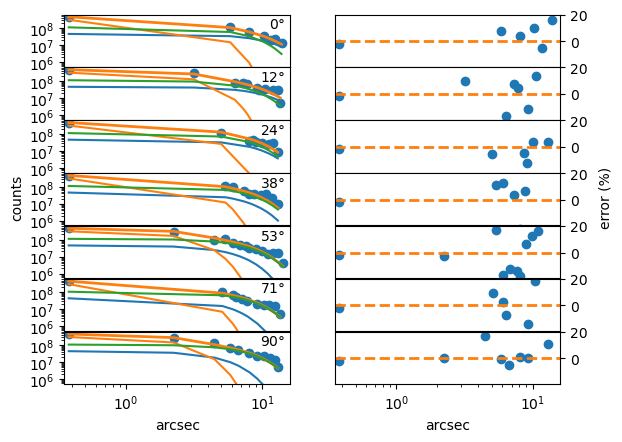

In [403]:
m = mge_fit_sectors(s.radius, s.angle, s.counts, f.eps,
                        ngauss=None, plot=1, bulge_disk=0, linear=1, 
                    # sigmapsf=5.08, normpsf=1
                   )

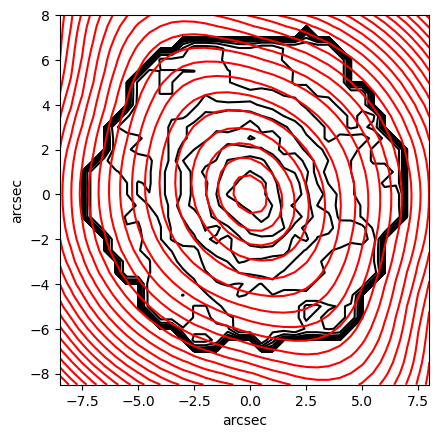

In [405]:
mge_print_contours(10**sMass, f.theta, f.xpeak, f.ypeak, m.sol, 
                   scale=0.5,
                       # sigmapsf=sigmapsf, normpsf=normpsf, 
                   # binning=9, 
                       minlevel=6
                  )

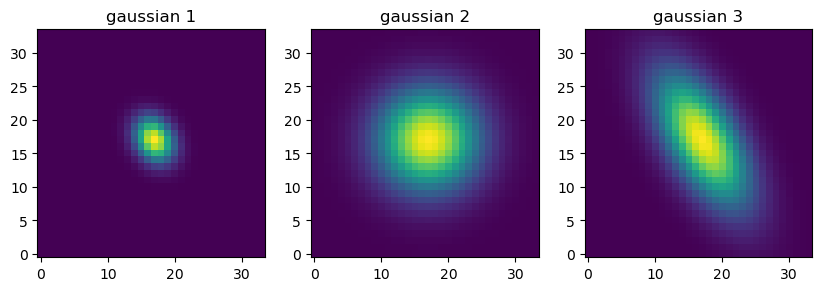

In [406]:
L, sigma, q_obs = m.sol
fig,ax = plt.subplots(1,3, figsize=(10,10))

for i in range(3):
    ax[i].imshow(L[i]/(2*np.pi*sigma[i]**2 * q_obs[i])*_gauss2d_mge(flux.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q_obs[i], f.theta))
    ax[i].set_title('gaussian ' + str(i+1))
    ax[i].invert_yaxis()


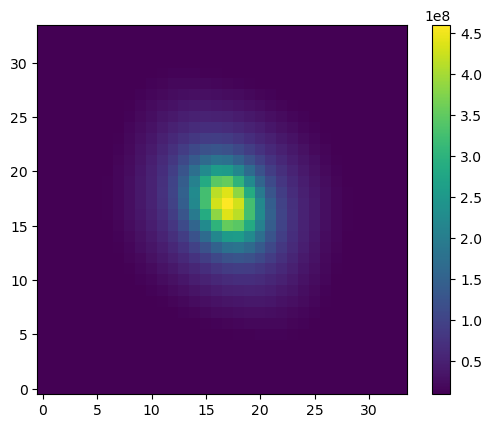

In [407]:
mge_flux=0.
for i in range(len(L)):
    mge_flux += L[i]/(2*np.pi*sigma[i]**2 * q_obs[i]) *_gauss2d_mge(flux.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q_obs[i], f.theta)

plt.imshow(mge_flux, vmin=10**7, vmax=4.6*10**8)
plt.colorbar()
plt.gca().invert_yaxis()

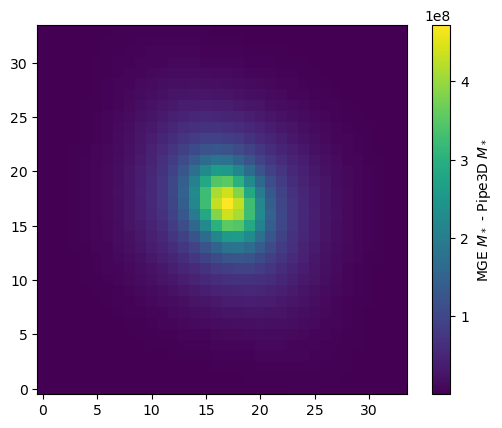

In [408]:
plt.imshow(mge_flux - flux)
plt.colorbar(label='MGE $M_*$ - Pipe3D $M_*$')
plt.gca().invert_yaxis()

### MGE for dark halo

In [455]:
def MGE_NFW(rs):

    r = np.geomspace(1,rs*10,300)
    rho = (r/rs)**-1 * (0.5 + 0.5*r/rs)**-2

    m = mge_fit_1d(r, rho, ngauss=15, quiet=1, plot=0)
    return m

def MGE_Burk(rs):

    r = np.geomspace(1,rs*10,300)
    rho = (1 + r/rs)**-1 * (1+(r/rs)**2)**-1

    m = mge_fit_1d(r, rho, ngauss=15, quiet=1, plot=0)
    return m

def MGE_Iso(rs):

    r = np.geomspace(1,rs*10,300)
    rho = (1 + (r/rs)**2)**-1

    m = mge_fit_1d(r, rho, ngauss=15, quiet=1, plot=0)
    return m

### trying a diff halo method

In [418]:
def MGE_NFW(rs, ps):

    r = np.geomspace(1,rs*10,300)
    rho = ps*(r/rs)**-1 * (0.5 + 0.5*r/rs)**-2

    m = mge_fit_1d(r, rho, ngauss=15, quiet=1, plot=0)
    return m

### function to attempt JAM model w free params

In [419]:
#rotate coordinates
center = (f.xpeak, f.ypeak)
im_axis = np.linspace(0, len(sMass)-1, len(sMass))
dist_x, dist_y = im_axis - f.xpeak, im_axis-f.ypeak
xs, ys = np.meshgrid(dist_x, dist_y)

rot_xs = xs*np.cos(np.radians(f.theta)) - ys*np.sin(np.radians(f.theta)) # angle is confusing?
rot_ys = xs*np.sin(np.radians(f.theta)) + ys*np.cos(np.radians(f.theta))



In [420]:
# remove the center from maps, coordinates
vel = np.zeros(len(sMass)**2 - 1)
# vel = np.delete(vel_maps['Ha_vel'], 595)
sig = np.delete(vel_maps['star_sigma'], 595)
# xbin = np.delete(rot_xs, center)
# ybin = np.delete(rot_ys, center)?
xbin = np.delete(rot_xs.flatten(), 595)
ybin = np.delete(rot_ys.flatten(), 595)

# xbin = np.delete(xs.flatten(), 595)
# ybin = np.delete(ys.flatten(), 595)

rms = np.sqrt(vel**2 + sig**2)                           # Vrms field in km/s


xbin = xbin[rms>0]
ybin = ybin[rms>0]
rms = rms[rms>0]

xbin=xbin*0.5 # dist in arcsec

ybin=ybin*0.5

In [449]:
def JAM_sph_halo(params):

    rs, f_dm, b, inc= params

    # b = params

    
    inc=inc
    
    sigma_a = np.array(sigma*0.5) #px-->arcsec
    sigma_pc = c*z/H_0 * 1000 * 1000 * np.tan(sigma_a*(1./60)*(1./60)*(np.pi/180)) #arcsec --> pc
    surf = np.array(L / (2*np.pi*q_obs*sigma_pc**2)) #Msun/px^2 --> Msun/pc^2
    
    
    qobs = np.array(q_obs)
    
    distance = c*z/H_0
    mbh = 0         # Black hole mass in solar masses
    
    beta = np.full_like(surf, b
                       )
   
    
    surf_lum = surf_pot = surf
    sigma_lum = sigma_pot = sigma_a
    qobs_lum = qobs_pot = qobs
    
    # sigmapsf = 2.54
    # normpsf = 1
    pixsize = 0.5
    # goodbins = r > 10  # Arbitrarily exclude the center to illustrate how to use goodbins
    
    
    
    # # first do MGE for halo
    m = MGE_NFW(rs) # in terms of Msun, px
    
    #unpack halo sol
    surf_dm, sigma_dm = m.sol           # Peak surface density (Msun/px**3) and sigma (px)
    qobs_dm = np.ones_like(surf_dm)



    # sigma_dm_pc = c*z/H_0 * 1000 * 1000 * np.tan(sigma_dm*pixsize*(1./60)*(1./60)*(np.pi/180)) #arcsec --> pc
    
    # surf_dm = dens_dm * np.sqrt(2*np.pi)*sigma_dm  # (Msun/px**2) --> (Msun/pc**2)



    
    # sigma_dm = sigma_dm*pixsize #(px--> arcsec)
    
    reff = jam.mge.half_light_radius(surf_lum, sigma_lum, qobs_lum)[0] # half light radius from stellar map MGE
    stars_lum_re = jam.mge.radial_mass(surf_lum, sigma_lum, qobs_lum, inc, reff) # stellar mass within re
    dark_mass_re = jam.mge.radial_mass(surf_dm, sigma_dm, qobs_dm, inc, reff) # dm mass within re
    
    f_dm=f_dm
    scale = (f_dm*stars_lum_re)/(dark_mass_re*(1 - f_dm))
    
    surf_pot = np.append(surf_lum, surf_dm*scale)   # Msun/pc**2. DM scaled so that f_DM(Re)=f_DM
    # surf_pot = np.append(surf_lum, surf_dm)   # Msun/pc**2. DM scaled so that f_DM(Re)=f_DM
    sigma_pot = np.append(sigma_lum, sigma_dm)      # Gaussian dispersion in arcsec
    qobs_pot = np.append(qobs_lum, qobs_dm)
    
    out = jam.axi.proj(surf_lum, sigma_lum, qobs_lum, surf_pot, sigma_pot, qobs_pot,
                               inc, mbh, distance, xbin, ybin, plot=1, pixsize=pixsize, pixang=0,
                           beta=beta, moment='zz', quiet=0, 
                            align='sph', data=rms, ml=None, logistic=False)
        

    return out.chi2

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 0.30
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0
inc=90.0; beta[0]=0.10; kappa=1.00; M/L=1.00; BH=0.0; chi2/DOF=29.7
Total mass MGE (MSun): 5.197e+10

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 0.30
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0
inc=90.0; beta[0]=0.10; kappa=1.00; M/L=1.00; BH=0.0; chi2/DOF=29.7
Total mass MGE (MSun): 5.197e+10

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 0.27
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0
inc=90.0; beta[0]=0.10; kappa=1.00; M/L=1.00; BH=0.0; chi2/DOF=29.7
Total mass MGE (MSun): 5.197e+10

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 0.28
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0
inc=90.0; beta[0]=0.10; kappa=1.00; M/L=1.00; BH=0.0; chi2/DOF=29.

AxisError: axis 1 is out of bounds for array of dimension 1

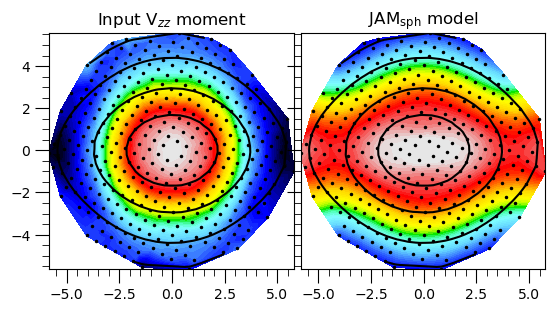

In [423]:
rs_0 = 5 # px
rs_bounds = (0.1, 1000) #px
# f_dm_0 = 0.1
# f_dm_bounds = (0,1)

ps_0 = 10**9 # Lsun
ps_bounds = (0,10**15)

# inc_0 = 79
# inc_bounds = (79, 90)

# qmin =


b_0 = 0.1
b_bounds = (0, np.inf)


x0 = [rs_0, ps_0 ,b_0]
bounds = ([rs_bounds[0], ps_bounds[0],  b_bounds[0]],
          [rs_bounds[1], ps_bounds[1],  b_bounds[1]])


# x0 = [b_0]
# bounds = (b_bounds[0],
#           b_bounds[1])

# x0 = [f_dm_0 ,b_0]
# bounds = ([f_dm_bounds[0],  b_bounds[0]],
#           [f_dm_bounds[1],  b_bounds[1]])

# x0 = [rs_0, f_dm_0]
# bounds = ([rs_bounds[0], f_dm_bounds[0]],
          # [rs_bounds[1], f_dm_bounds[1]])
# bounds = [rs_bounds, f_dm_bounds, inc_bounds, b_bounds]

res = least_squares(JAM_sph_halo, x0, bounds=bounds)
# JAM_sph_halo(x0)

In [416]:
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 1.332e+01]
           x: [ 3.190e+00  6.503e-09  5.203e-01]
        cost: 88.69780475565447
         jac: [[ 3.737e-08  2.589e+01  7.817e-04]]
        grad: [ 4.978e-07  3.449e+02  1.041e-02]
  optimality: 0.0054166107598288766
 active_mask: [ 0 -1  0]
        nfev: 67
        njev: 53

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 0.38
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0
inc=90.0; beta[0]=0.52; kappa=1.00; M/L=1.00; BH=0.0; chi2/DOF=13.3
Total mass MGE (MSun): 3.433e+10



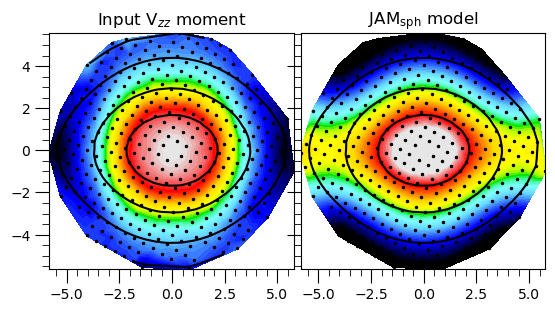

In [417]:
best_fit = JAM_sph_halo(res.x)

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 0.29
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0
inc=90.0; beta[0]=0.10; kappa=1.00; M/L=1.00; BH=0.0; chi2/DOF=49.8
Total mass MGE (MSun): 1.975e+16

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 0.28
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0
inc=90.0; beta[0]=0.10; kappa=1.00; M/L=1.00; BH=0.0; chi2/DOF=49.8
Total mass MGE (MSun): 1.975e+16

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 0.29
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0
inc=90.0; beta[0]=0.10; kappa=1.00; M/L=1.00; BH=0.0; chi2/DOF=49.8
Total mass MGE (MSun): 1.975e+16

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 0.29
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0
inc=90.0; beta[0]=0.10; kappa=1.00; M/L=1.00; BH=0.0; chi2/DOF=49.

KeyboardInterrupt: 

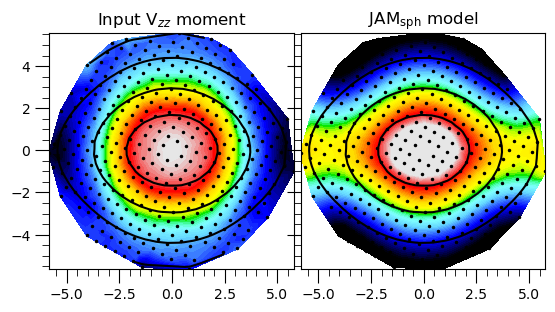

In [413]:
res = least_squares(JAM_sph_halo, x0, bounds=bounds)

In [277]:
res

     message: `xtol` termination condition is satisfied.
     success: True
      status: 3
         fun: [ 9.775e+00]
           x: [ 2.000e+05  1.088e-03  2.383e-01]
        cost: 47.77518561247512
         jac: [[ 4.250e-10  1.002e+02  9.057e-01]]
        grad: [ 4.154e-09  9.792e+02  8.853e+00]
  optimality: 2.1093602707384878
 active_mask: [0 0 0]
        nfev: 20
        njev: 13

jam.axi.proj(align='cyl', moment='zz') -- elapsed time sec: 0.04
analytic_los=1 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0
inc=90.0; beta[0]=0.24; kappa=1.00; M/L=1.00; BH=0.0; chi2/DOF=9.77
Total mass MGE (MSun): 3.002e+17



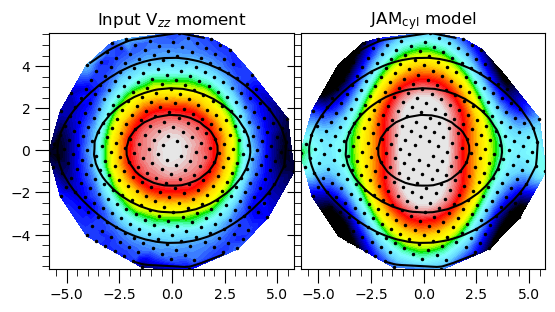

In [280]:
best_fit, model = JAM_sph_halo(res.x)

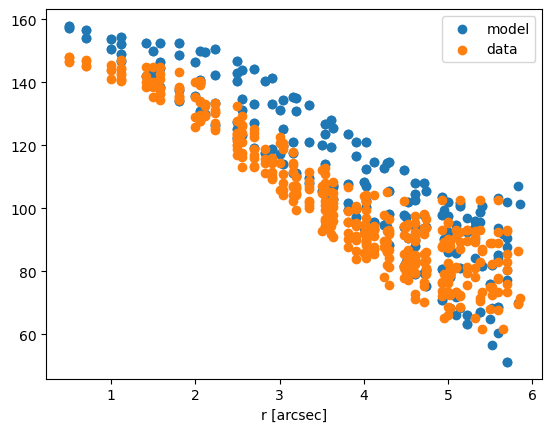

In [286]:
plt.scatter(np.sqrt(xbin**2 + ybin**2), model, label='model') 
plt.scatter(np.sqrt(xbin**2+ ybin**2), rms, label='data')
plt.xlabel('r [arcsec]')
plt.legend()

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 0.29
analytic_los=0 logistic=1 constant_anisotropy=0
No PSF/pixel convolution because sigmapsf=0
inc=90.0; beta[1]=0.20; kappa=1.00; M/L=0.555; BH=0.0; chi2/DOF=10.5
Total mass MGE (MSun): 1.949e+10



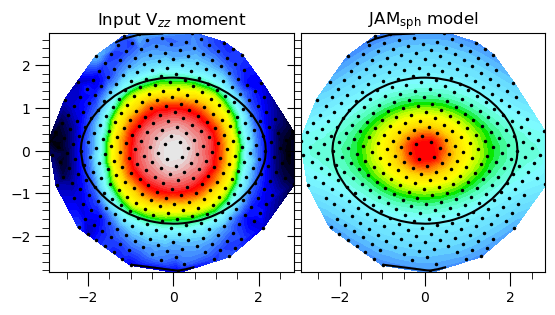

In [23]:
sigma_a = np.array(sigma*0.5) #px-->arcsec
sigma_pc = c*z/H_0 * 1000 * 1000 * np.tan(sigma_a*(1./60)*(1./60)*(np.pi/180)) #arcsec --> pc
surf = np.array(L / (2*np.pi*q_obs*sigma_pc**2)) #Msun/px^2 --> Msun/pc^2


qobs = np.array(q_obs)

distance = c*z/H_0
mbh = 0         # Black hole mass in solar masses

beta = np.full_like(surf, 0.1
                   )

# As alternative to setting the anisotropy of each individual Gaussian, one
# can specify an analytic radial variation for the anisotropy, of the form
#
#   beta(r) = beta_0 + (beta_inf - beta_0)/[1 + (r_a/r)^alpha]    # with align='sph'
# beta(z) = beta_0 + (beta_inf - beta_0)/[1 + (z_a/|z|)^alpha]  # with align='cyl'
#
# by specifying beta as a list of 4-element as follows (see documentation):
#
r_a = 1        # Anisotropy transition radius in arcsec
beta_0 = 0.2    # Inner anisotropy
beta_inf = 0.4  # Outer anisotropy
alpha = 1       # Sharpness of the anisotropy transition
beta = [r_a, beta_0, beta_inf, alpha]

# Below I assume mass follows light, but in a real application one
# will generally include a dark halo in surf_pot, sigma_pot, qobs_pot.
# See jam_dark_halo_bayes_example.py and e.g. Cappellari (2013) for an example
# https://ui.adsabs.harvard.edu/abs/2013MNRAS.432.1709C

surf_lum = surf_pot = surf
sigma_lum = sigma_pot = sigma_a
qobs_lum = qobs_pot = qobs

# sigmapsf = 2.54
# normpsf = 1
pixsize = 0.5
# goodbins = r > 10  # Arbitrarily exclude the center to illustrate how to use goodbins


plt.figure(1)
out = jam.axi.proj(surf_lum, sigma_lum, qobs_lum, surf_pot, sigma_pot, qobs_pot,
                       inc, mbh, 
                   distance, 
                   xbin, ybin, plot=True, data=rms,
                       # sigmapsf=sigmapsf, normpsf=normpsf, 
                       beta=beta, 
                       pixsize=pixsize,
                       moment='zz',
                       #goodbins=goodbins,
                       align='sph', ml=None,
                      pixang=f.theta,
                  logistic=True,
                  )
surf_pot *= out.ml  # Scale the density by the best fitting M/L from the previous step

## test galaxy 2

In [290]:
# FILE_IDS= ['8143-3704', '8592-1901']
FILE_IDS= ['8143-3704?']

### first perform multi gaussian expansion

In [291]:
H_0 = 100      # Hubble's Constant in units of h km/s/Mpc
c = 299792.458 # Speed of light in units of km/s

In [341]:
gal_ID = '8143-3704'
    
idx = master_table_dict[gal_ID]
sMass_maps = extract_Pipe3d_data(PIPE3D_FOLDER, gal_ID, ['sMass'])
flux_maps = extract_data(VEL_FOLDER, gal_ID, ['flux'])
vel_maps = extract_data(VEL_FOLDER, gal_ID, ['flux', 'Ha', 'star_sigma'])
PA = master_table[idx]['nsa_elpetro_phi']
ba = master_table[idx]['nsa_elpetro_ba']
z = master_table[idx]['nsa_z']

sMass = sMass_maps['sMass_density']
flux = flux_maps['mflux']
mask = np.logical_or(np.isnan(sMass), sMass == 0)
msMass = ma.array(sMass, mask = mask)
fmask = flux <= 0
mflux = ma.array(flux, mask=fmask)

Text(0, 0.5, 'spaxel')

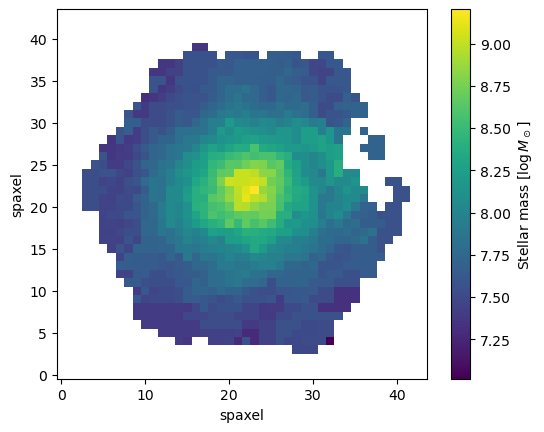

In [342]:
plt.imshow(sMass)
plt.gca().invert_yaxis()
plt.colorbar(label= r'Stellar mass $[\log M_\odot]$')
plt.xlabel('spaxel')
plt.ylabel('spaxel')

Text(0, 0.5, 'spaxel')

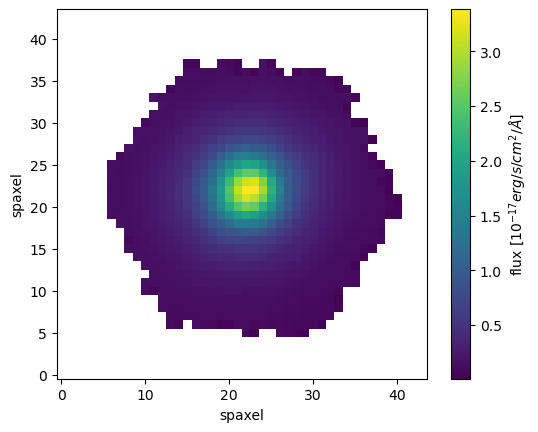

In [343]:
plt.imshow(mflux)
plt.gca().invert_yaxis()
plt.colorbar(label= r'flux $[10^{-17} erg/s/cm^2/\AA]$')
plt.xlabel('spaxel')
plt.ylabel('spaxel')

Text(0, 0.5, 'spaxel')

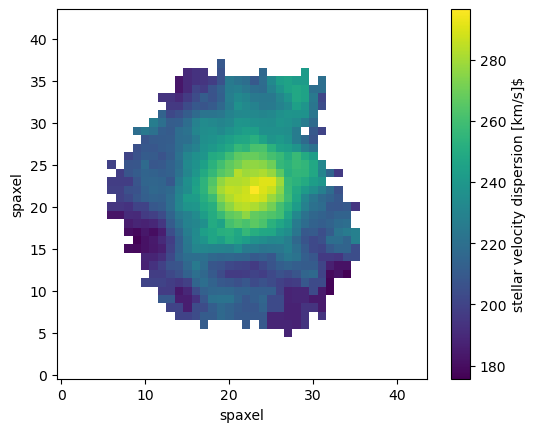

In [344]:
plt.imshow(ma.array(vel_maps['star_sigma'], mask=vel_maps['star_sigma_mask']))
plt.gca().invert_yaxis()
plt.colorbar(label= r'stellar velocity dispersion [km/s]$')
plt.xlabel('spaxel')
plt.ylabel('spaxel')

In [345]:
sn_mask = np.logical_and(vel_maps['star_sigma_mask'], vel_maps['star_sigma']*np.sqrt(vel_maps['star_sigma_ivar'])>10)

Text(0, 0.5, 'spaxel')

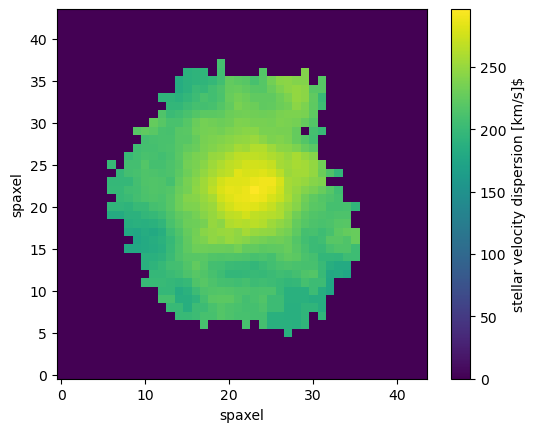

In [346]:
plt.imshow(ma.array(vel_maps['star_sigma'], mask=sn_mask))
plt.gca().invert_yaxis()
plt.colorbar(label= r'stellar velocity dispersion [km/s]$')
plt.xlabel('spaxel')
plt.ylabel('spaxel')

In [347]:
sn10_mask = np.logical_or(vel_maps['star_sigma'] * 
                               np.sqrt(vel_maps['star_sigma_ivar']) < 10, 
                               vel_maps['star_sigma_mask'])

Text(0, 0.5, 'spaxel')

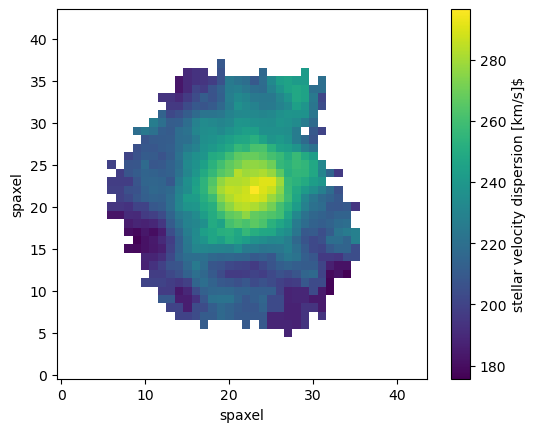

In [348]:
plt.imshow(ma.array(vel_maps['star_sigma'], mask=sn10_mask))
plt.gca().invert_yaxis()
plt.colorbar(label= r'stellar velocity dispersion [km/s]$')
plt.xlabel('spaxel')
plt.ylabel('spaxel')

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  4., 11., 12., 41.,
        10., 23., 37., 33., 61., 88., 37., 53., 58., 31., 48., 40., 19.,
        22., 20., 25., 29.,  9., 27.,  6., 20., 21., 18., 17., 10., 15.,
        14., 14., 12., 13.,  7.,  7.,  9., 10.,  5.,  5.,  5.,  5.,  6.,
         5.,  2.,  8.,  9.,  2.,  2.,  5.,  4.,  2.,  2.,  0.,  0.,  2.,
         4.,  6.,  1.,  1.,  1.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]),
 array([ 7.        ,  7.03030303,  7.06060606,  7.09090909,  7.12121212,
         7.15151515,  7.18181818,  7.21212121,  7.24242424,  7.27272727,
         7.3030303 ,  7.33333333,  7.36363636,  7.39393939,  7.42424242,
         7.45454545,  7.48484848,  7.51515152,  7.54545455,  7.57575758,
         7.60606061,  7.63636364,  7.66666667,  7.6969697 ,  7.72727273,
         7.75757576,  7.78787879,  7.81818182,  7.84848485,  7.87878788,
 

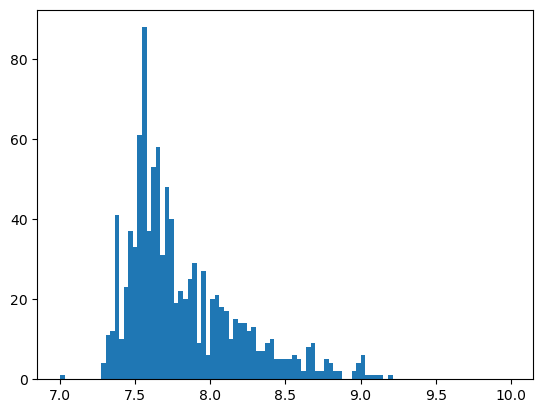

In [349]:
plt.hist(sMass.flatten(), 
         bins=np.linspace(7,10,100)
        )

In [350]:
# set all points that should be masked to 0
sMass[mask]=0.

 Pixels used: 192
 Peak Img[j, k]: 22 22
 Mean (j, k): 22.03 22.19
 Theta (deg): 149.3
 Astro PA (deg): 120.7
 Eps: 0.073
 Major axis (pix): 8.1


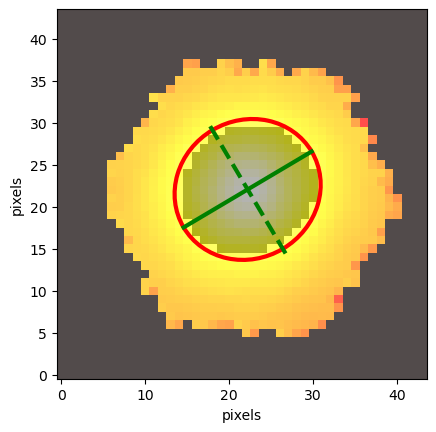

In [351]:
f = find_galaxy(flux, fraction=0.1, plot=True,)

 Pixels used: 194
 Peak Img[j, k]: 22 23
 Mean (j, k): 22.29 22.59
 Theta (deg): 157.4
 Astro PA (deg): 112.6
 Eps: 0.169
 Major axis (pix): 10.5


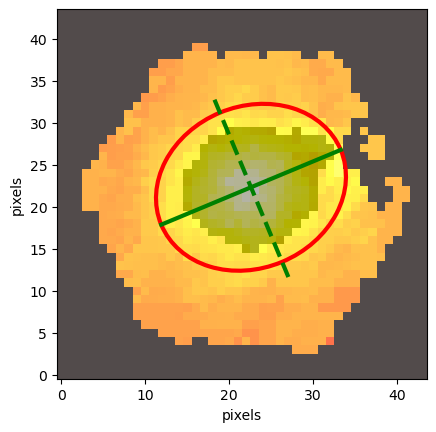

In [352]:
f = find_galaxy(10**sMass, fraction=0.1, plot=True,)

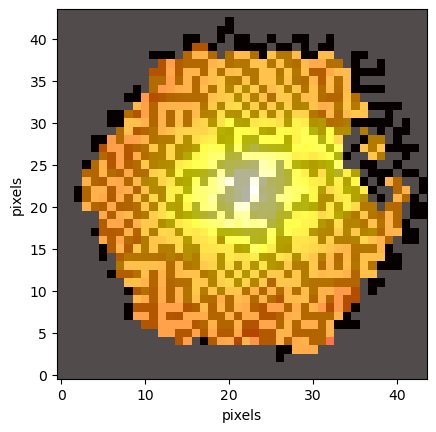

In [353]:
s = sectors_photometry(10**sMass, f.eps, f.theta, f.xpeak, f.ypeak,
                            plot=1, minlevel=6, #mask=sMass==0
                      )

Starting the LINEAR fit with  10000  Gaussians. Please wait...
Nonzero Gaussians: 8/10000
Eliminating not useful Gaussians...
ngauss: 7          chi2: 27.32
ngauss: 6          chi2: 27.32
ngauss: 5          chi2: 27.32
ngauss: 4          chi2: 27.36
Starting nonlinear fit...
Iteration: 0  chi2: 27.36  Nonzero: 4/4
Iteration: 4  chi2: 27.31  Nonzero: 4/4
Nonzero Gaussians: 4/4
Eliminating not useful Gaussians...
All Gaussians are needed!
############################################
  Computation time: 1.10 seconds
  Total Iterations:  0
 Nonzero Gaussians:  4
  Unused Gaussians:  9996
 Sectors used in the fit:  19
 Total number of points fitted:  286
 Chi2: 27.31 
 STDEV: 0.2939 
 MEANABSDEV: 0.2122 
############################################
  Total_Counts   sigma_Pixels     q_obs
############################################
   5.7487e+08       0.3800       0.0500
   2.4520e+10        2.244       1.0000
   7.8315e+09        3.891       0.5810
   6.9423e+10        7.079       0.9438
+

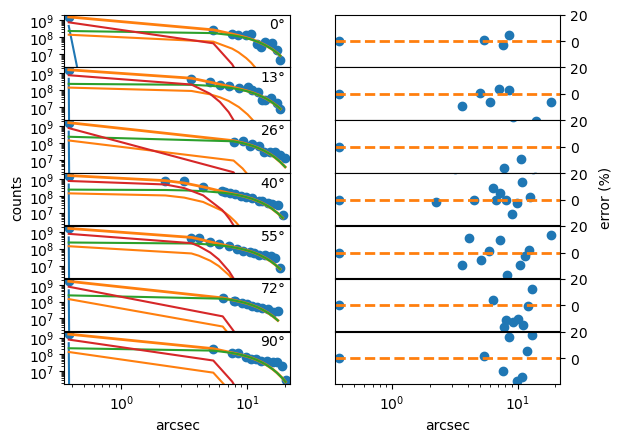

In [354]:
m = mge_fit_sectors(s.radius, s.angle, s.counts, f.eps,
                        ngauss=None, plot=1, bulge_disk=0, linear=1, 
                    # sigmapsf=5.08, normpsf=1
                   )

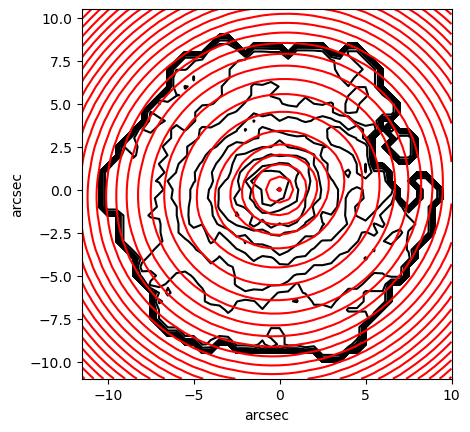

In [355]:
mge_print_contours(10**sMass, f.theta, f.xpeak, f.ypeak, m.sol, 
                   scale=0.5,
                       # sigmapsf=sigmapsf, normpsf=normpsf, 
                   # binning=9, 
                       minlevel=6
                  )

In [362]:
L

array([5.74874167e+08, 2.45195533e+10, 7.83149682e+09, 6.94225558e+10])

In [363]:
sigma

array([0.38      , 2.24377397, 3.89054417, 7.07902546])

In [364]:
q_obs

array([0.05      , 1.        , 0.58101536, 0.9438414 ])

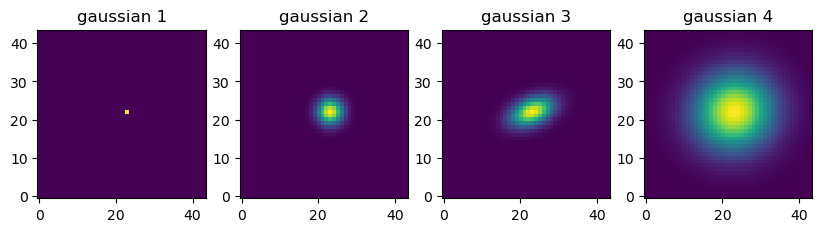

In [356]:
L, sigma, q_obs = m.sol
fig,ax = plt.subplots(1,len(L), figsize=(10,10))

for i in range(len(L)):
    ax[i].imshow(L[i]/(2*np.pi*sigma[i]**2 * q_obs[i])*_gauss2d_mge(flux.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q_obs[i], f.theta))
    ax[i].set_title('gaussian ' + str(i+1))
    ax[i].invert_yaxis()


(array([ 19.,  62., 141., 311., 426., 438., 400., 118.,  20.,   1.]),
 array([ 3.74211385,  4.38196197,  5.02181008,  5.6616582 ,  6.30150631,
         6.94135443,  7.58120254,  8.22105066,  8.86089877,  9.50074689,
        10.140595  ]),
 <BarContainer object of 10 artists>)

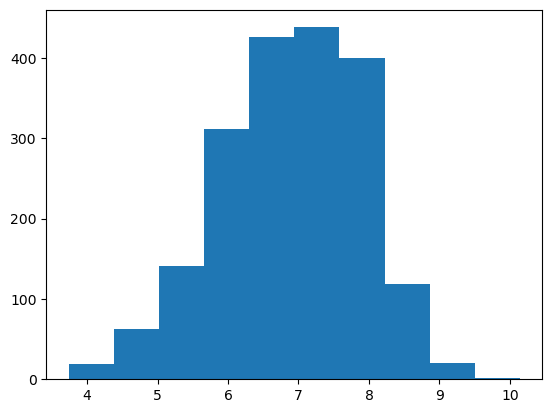

In [370]:
plt.hist(np.log10(mge_flux).flatten())

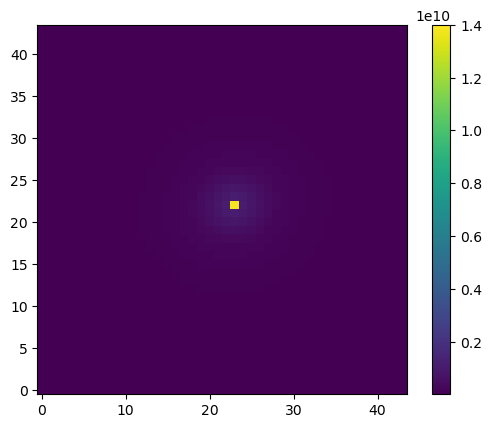

In [365]:
mge_flux=0.
for i in range(len(L)):
    mge_flux += L[i]/(2*np.pi*sigma[i]**2 * q_obs[i]) *_gauss2d_mge(flux.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q_obs[i], f.theta)

plt.imshow(mge_flux, 
           vmin=10**7, vmax=1.4*10**10
          )
plt.colorbar()
plt.gca().invert_yaxis()

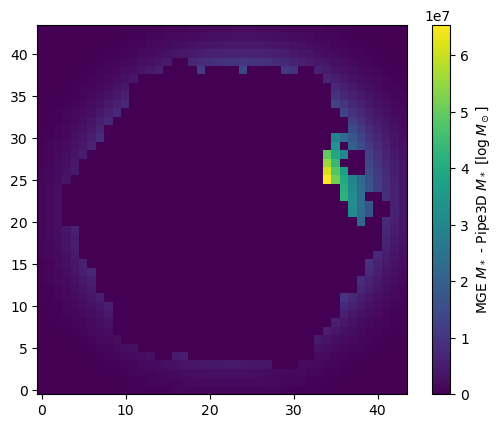

In [360]:
plt.imshow((mge_flux - 10**sMass)/10**sMass)
plt.colorbar(label=r'MGE $M_*$ - Pipe3D $M_*$ $[\log M_\odot]$')
plt.gca().invert_yaxis()

### JAM 

In [380]:
#rotate coordinates
center = (f.xpeak, f.ypeak)
im_axis = np.linspace(0, len(sMass)-1, len(sMass))
dist_x, dist_y = im_axis - f.xpeak, im_axis-f.ypeak
xs, ys = np.meshgrid(dist_x, dist_y)

rot_xs = xs*np.cos(np.radians(f.theta)) - ys*np.sin(np.radians(f.theta)) # angle is confusing?
rot_ys = xs*np.sin(np.radians(f.theta)) + ys*np.cos(np.radians(f.theta))



In [385]:
center_flat = np.ravel_multi_index((f.xpeak, f.ypeak), (len(sMass), len(sMass)))
center_flat

991

In [386]:
len(sMass)

44

In [382]:
np.where(rot_xs==0)

(array([23]), array([22]))

In [383]:
np.where(rot_xs.flatten() == 0)

(array([1034]),)

In [376]:
# remove the center from maps, coordinates
vel = np.zeros(len(sMass)**2 - 1)
# vel = np.delete(vel_maps['Ha_vel'], 595)
sig=vel_maps['star_sigma']
# sig[sn10_mask]=0
sig = np.delete(sig, center_flat)
# xbin = np.delete(rot_xs, center)
# ybin = np.delete(rot_ys, center)?
xbin = np.delete(rot_xs.flatten(), center_flat)
ybin = np.delete(rot_ys.flatten(), center_flat)
goodbins = np.delete(sn10_mask.flatten(), center_flat)

# xbin = np.delete(xs.flatten(), 595)
# ybin = np.delete(ys.flatten(), 595)

rms = np.sqrt(vel**2 + sig**2)                           # Vrms field in km/s


xbin = xbin[rms>0]
ybin = ybin[rms>0]
# goodbins=goodbins[rms>0]
rms = rms[rms>0]

xbin=xbin*0.5 # dist in arcsec

ybin=ybin*0.5

In [378]:
rs_0 = 200000
rs_bounds = (5000, 250000)
f_dm_0 = 0.1
f_dm_bounds = (0,1)

# inc_0 = 79
# inc_bounds = (79, 90)

# qmin =


b_0 = 0.1
b_bounds = (0, np.inf)


x0 = [rs_0, f_dm_0 ,b_0]
bounds = ([rs_bounds[0], f_dm_bounds[0],  b_bounds[0]],
          [rs_bounds[1], f_dm_bounds[1],  b_bounds[1]])
# bounds = [rs_bounds, f_dm_bounds, inc_bounds, b_bounds]

res = least_squares(JAM_sph_halo, x0, bounds=bounds)
# JAM_sph_halo(x0)

ValueError: Geometric sequence cannot include zero

In [122]:
res

     message: `xtol` termination condition is satisfied.
     success: True
      status: 3
         fun: [ 1.449e+01]
           x: [ 2.000e+05  9.385e-02  1.233e-01]
        cost: 104.95129409050766
         jac: [[ 5.931e-08  7.869e+00 -1.073e-01]]
        grad: [ 8.593e-07  1.140e+02 -1.555e+00]
  optimality: 10.700000026548759
 active_mask: [0 0 0]
        nfev: 5
        njev: 4

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 0.50
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0
inc=90.0; beta[0]=0.12; kappa=1.00; M/L=1.00; BH=0.0; chi2/DOF=14.5
Total mass MGE (MSun): 3.151e+19



14.48801532926492

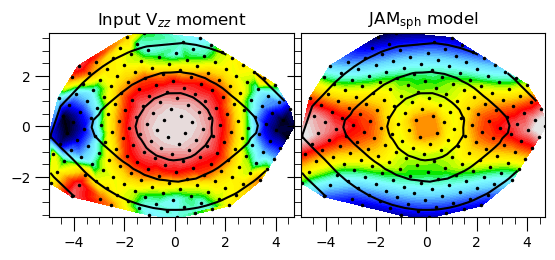

In [123]:
JAM_sph_halo(res.x)

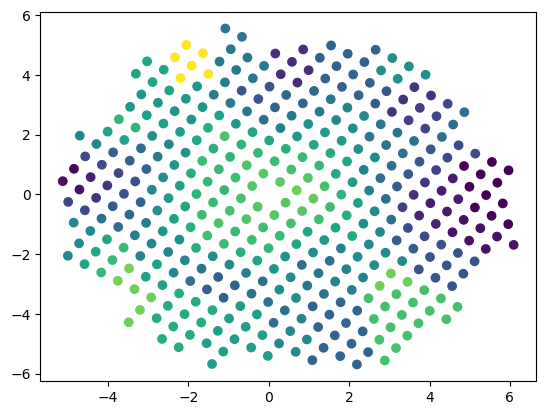

In [78]:
plt.scatter(xbin, ybin, c=rms)

## try using info from DynPop

In [426]:
dynpop_1 = Table.read(DATA_FOLDER + '/dynpop/SDSSDR17_MaNGA_JAM.fits', hdu=1)
dynpop_sph_nfw = Table.read(DATA_FOLDER + '/dynpop/SDSSDR17_MaNGA_JAM.fits', hdu=5)
dynpop_cyl_nfw = Table.read(DATA_FOLDER + '/dynpop/SDSSDR17_MaNGA_JAM.fits', hdu=4)

In [428]:
master_table[master_table_dict[test_gal]]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64

In [431]:
dynpop_dict = {}
for i in range(len(dynpop)):
    dynpop_dict[dynpop['plateifu'][i]] = i

In [433]:
d_idx = dynpop_dict[test_gal]
dynpop[d_idx]

plate,ifudsgn,plateifu,mangaid,obj_ra,obj_dec,ebvgal,target,DA,rmax_arcsec,Re_arcsec_MGE,Rmaj_arcsec_MGE,Lum_tot_MGE,Lambda_Re,Sigma_Re,Eps_MGE,PA_phot,PA_kin,PA_kin_flag,nsa_iauname,z,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_id,nsa_nsaid_v1b,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_sersic_mass,nsa_elpetro_mass,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,Qual,drp3qual
int32,int32,bytes15,bytes15,float64,float64,float64,int32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes20,float64,int32,int32,int32,bytes15,bytes15,bytes15,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64[7],int32,int32
8319,1902,8319-1902,1-285062,199.381778619,47.6766457959,0.00835949,0,115.522,5.7032416663749865,3.695983422890308,3.9673793070832195,10.116,0.343,131.8,0.165,38.937,62.0,1.0,J131731.62+474035.9,0.0269767,103,3716,6,v1_0_1,301373,-999,-12.1504 .. -20.6089,-12.282 .. -20.3505,10.092829380092908,10.059964585786684,0.792225,6.0,39.5676,1.81695,1.01233 .. 2569.27,3,1


In [434]:
dynpop_cyl_nfw[d_idx]

inc_deg,beta_z,log_ML_stellar,log_rho_s,rs,kappa,log_Mt_Re,log_Ms_Re,log_Md_Re,fdm_Re,log_ML_dyn_Re,chi2_dof,rhalf_arcsec,log_Mt_rhalf,log_Ms_rhalf,log_Md_rhalf,MW_Gt_Re,MW_Gs_Re,MW_Gd_Re,MW_Gt_rhalf,MW_Gs_rhalf,MW_Gd_rhalf,Gt_Re,Gs_Re,Gd_Re
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
32.852,0.434,0.51,0.8959400086720376,29.356,1.386,10.358,10.357,4.357,0.0,0.51,0.036961,3.2174696270764906,10.326,10.325,4.241,2.477,2.477,1.079,2.463,2.462,1.056,-2.704,-2.704,-1.069


In [435]:
dynpop_sph_nfw[d_idx]

inc_deg,beta_r,log_ML_stellar,log_rho_s,rs,kappa,log_Mt_Re,log_Ms_Re,log_Md_Re,fdm_Re,log_ML_dyn_Re,chi2_dof,rhalf_arcsec,log_Mt_rhalf,log_Ms_rhalf,log_Md_rhalf,MW_Gt_Re,MW_Gs_Re,MW_Gd_Re,MW_Gt_rhalf,MW_Gs_rhalf,MW_Gd_rhalf,Gt_Re,Gs_Re,Gd_Re
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
37.214,0.434,0.483,5.158940008672038,27.985,1.654,10.327,10.318,8.598,0.019,0.492,0.036638,3.4120890440306177,10.306,10.298,8.531,2.414,2.438,1.082,2.404,2.426,1.067,-2.552,-2.594,-1.072


In [436]:
hdu = fits.open(DATA_FOLDER + '/DR17/8319/1902/manga-8319-1902-LINCUBE.fits.gz')
rimg = hdu[13].data

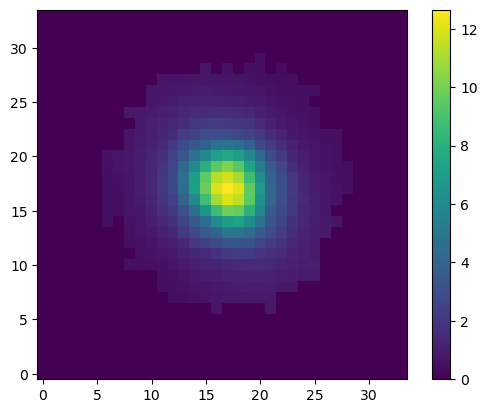

In [439]:
plt.imshow(rimg)
plt.gca().invert_yaxis()
plt.colorbar()

 Pixels used: 116
 Peak Img[j, k]: 17 17
 Mean (j, k): 17.08 17.11
 Theta (deg): 58.8
 Astro PA (deg): 31.2
 Eps: 0.130
 Major axis (pix): 6.4


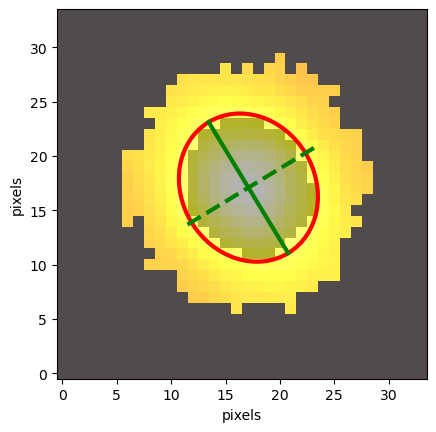

In [440]:
f = find_galaxy(rimg, fraction=0.1, plot=True)

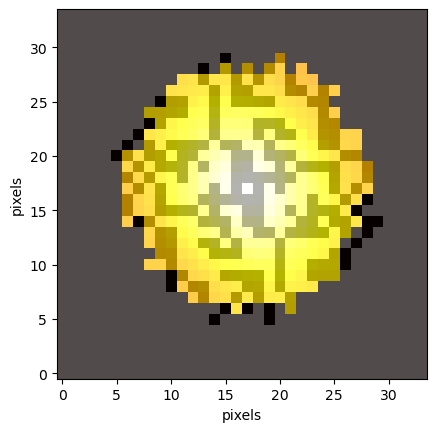

In [441]:
s = sectors_photometry(rimg, f.eps, f.theta, f.xpeak, f.ypeak,
                            plot=1, minlevel=0.1, #mask=sMass==0
                      )

Starting the LINEAR fit with  10000  Gaussians. Please wait...
Nonzero Gaussians: 6/10000
Eliminating not useful Gaussians...
ngauss: 5          chi2: 7.477
ngauss: 4          chi2: 7.488
Starting nonlinear fit...
Iteration: 0  chi2: 7.488  Nonzero: 4/4
Iteration: 3  chi2: 7.478  Nonzero: 4/4
Nonzero Gaussians: 4/4
Eliminating not useful Gaussians...
All Gaussians are needed!
############################################
  Computation time: 0.58 seconds
  Total Iterations:  0
 Nonzero Gaussians:  4
  Unused Gaussians:  9996
 Sectors used in the fit:  19
 Total number of points fitted:  176
 Chi2: 7.478 
 STDEV: 0.2017 
 MEANABSDEV: 0.1305 
############################################
  Total_Counts   sigma_Pixels     q_obs
############################################
   1.4342e+02        1.933       1.0000
   1.4352e+02        3.965       0.6144
   5.6806e+02        4.682       1.0000
   1.3788e+01        6.185       0.0944
++++++++++++++++++++++++++++++++++++++++++++


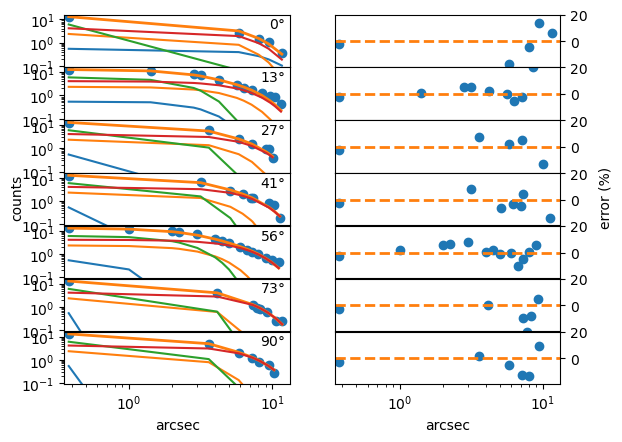

In [442]:
m = mge_fit_sectors(s.radius, s.angle, s.counts, f.eps,
                        ngauss=None, plot=1, bulge_disk=0, linear=1, 
                    # sigmapsf=5.08, normpsf=1
                   )

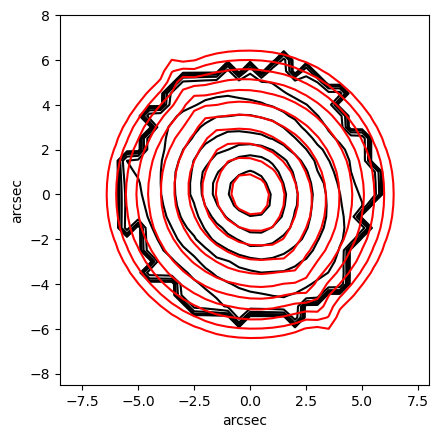

In [443]:
mge_print_contours(rimg, f.theta, f.xpeak, f.ypeak, m.sol, 
                   scale=0.5,
                       # sigmapsf=sigmapsf, normpsf=normpsf, 
                   # binning=9, 
                       minlevel=0.1
                  )

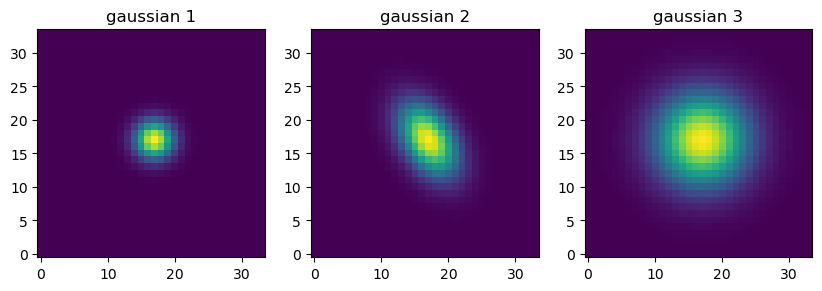

In [444]:
L, sigma, q_obs = m.sol
fig,ax = plt.subplots(1,3, figsize=(10,10))

for i in range(3):
    ax[i].imshow(L[i]/(2*np.pi*sigma[i]**2 * q_obs[i])*_gauss2d_mge(flux.shape, f.xpeak, f.ypeak, sigma[i], sigma[i]*q_obs[i], f.theta))
    ax[i].set_title('gaussian ' + str(i+1))
    ax[i].invert_yaxis()

In [459]:
#rotate coordinates
center = (f.xpeak, f.ypeak)
im_axis = np.linspace(0, len(rimg)-1, len(rimg))
dist_x, dist_y = im_axis - f.xpeak, im_axis-f.ypeak
xs, ys = np.meshgrid(dist_x, dist_y)

rot_xs = xs*np.cos(np.radians(f.pa)) - ys*np.sin(np.radians(f.pa)) # angle is confusing?
rot_ys = xs*np.sin(np.radians(f.pa)) + ys*np.cos(np.radians(f.pa))



In [460]:
# remove the center from maps, coordinates
vel = np.zeros(len(sMass)**2 - 1)
# vel = np.delete(vel_maps['Ha_vel'], 595)
sig = np.delete(vel_maps['star_sigma'], 595)
# xbin = np.delete(rot_xs, center)
# ybin = np.delete(rot_ys, center)?
xbin = np.delete(rot_xs.flatten(), 595)
ybin = np.delete(rot_ys.flatten(), 595)

# xbin = np.delete(xs.flatten(), 595)
# ybin = np.delete(ys.flatten(), 595)

rms = np.sqrt(vel**2 + sig**2)                           # Vrms field in km/s


xbin = xbin[rms>0]
ybin = ybin[rms>0]
rms = rms[rms>0]

xbin=xbin*0.5 # dist in arcsec

ybin=ybin*0.5

jam.axi.proj(align='sph', moment='zz') -- elapsed time sec: 0.31
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0
inc=90.0; beta[0]=0.43; kappa=1.00; M/L=3.57e+07; BH=0.0; chi2/DOF=7.60
Total mass MGE (MSun): 1.141e+17



7.60135293206463

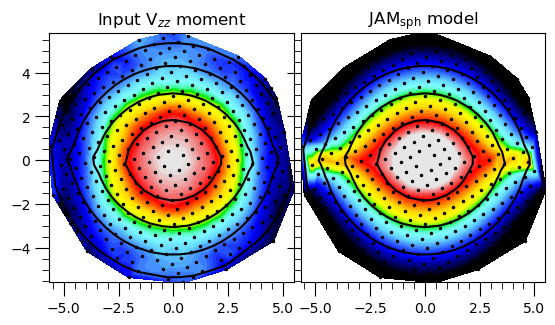

In [464]:
JAM_sph_halo([27985, 0.019, 0.434, 90])

In [458]:
dynpop_sph_nfw[d_idx]

inc_deg,beta_r,log_ML_stellar,log_rho_s,rs,kappa,log_Mt_Re,log_Ms_Re,log_Md_Re,fdm_Re,log_ML_dyn_Re,chi2_dof,rhalf_arcsec,log_Mt_rhalf,log_Ms_rhalf,log_Md_rhalf,MW_Gt_Re,MW_Gs_Re,MW_Gd_Re,MW_Gt_rhalf,MW_Gs_rhalf,MW_Gd_rhalf,Gt_Re,Gs_Re,Gd_Re
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
37.214,0.434,0.483,5.158940008672038,27.985,1.654,10.327,10.318,8.598,0.019,0.492,0.036638,3.4120890440306177,10.306,10.298,8.531,2.414,2.438,1.082,2.404,2.426,1.067,-2.552,-2.594,-1.072


In [466]:
master_table[master_table['mangaid'] == '1-209049']

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64

In [467]:
dynpop_sph_nfw[dynpop_dict['8486-3701']]

inc_deg,beta_r,log_ML_stellar,log_rho_s,rs,kappa,log_Mt_Re,log_Ms_Re,log_Md_Re,fdm_Re,log_ML_dyn_Re,chi2_dof,rhalf_arcsec,log_Mt_rhalf,log_Ms_rhalf,log_Md_rhalf,MW_Gt_Re,MW_Gs_Re,MW_Gd_Re,MW_Gt_rhalf,MW_Gs_rhalf,MW_Gd_rhalf,Gt_Re,Gs_Re,Gd_Re
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2.574,-2.488,1.278,5.784940008672037,250.0,-0.58,12.253,12.014,11.879,0.423,1.516,0.062136,2.706335339754431,12.116,11.94,11.639,1.881,2.436,1.121,1.967,2.402,1.094,-1.843,-2.553,-1.111
